# Machine Learning: Where the Discrete Math Shows Up

This final notebook is a **capstone**. Machine learning can look like a separate world of "AI," but it is built on exactly the discrete structures from this course. Here we connect the dots and build two small classifiers.

| Discrete structure (notebook) | Role in machine learning |
|---|---|
| **Sets & functions** (01, 09) | A dataset is a set of examples; a model is a *function* from inputs to predicted labels |
| **Matrices** (05) | Data is stored as matrices; training is linear algebra on them |
| **Counting & probability** (15) | Probabilistic models (e.g. Naive Bayes) are built from counts and combinatorics |
| **Trees** (11) | A *decision tree* classifier is literally a binary tree |
| **Graphs** (12) | Neural networks are weighted directed graphs of computations |

We will use `numpy`, `matplotlib`, and `scikit-learn`.

## A Small Classification Dataset

We generate a simple two-class dataset in the plane: two clusters of points, each a "class." Each example is a point $\mathbf{x} = (x_1, x_2)$ with a label $y \in \{0, 1\}$. The whole dataset is the matrix `X` (one row per point) and the label vector `y` — the **matrices** of notebook 05 and a **function** $\mathbf{x} \mapsto y$ we want to learn.

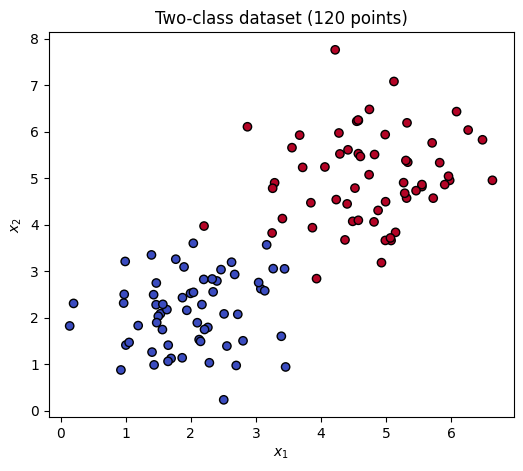

training points: 96, test points: 24


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
n = 60
class0 = rng.normal(loc=[2, 2], scale=0.8, size=(n, 2))
class1 = rng.normal(loc=[5, 5], scale=0.9, size=(n, 2))

X = np.vstack([class0, class1])
y = np.array([0] * n + [1] * n)

# Shuffle, then split into training and test sets (an 80/20 holdout).
order = rng.permutation(len(X))
X, y = X[order], y[order]
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$")
plt.title(f"Two-class dataset ({len(X)} points)")
plt.show()
print(f"training points: {len(X_train)}, test points: {len(X_test)}")

## Classifier 1: $k$-Nearest Neighbors (from scratch)

The **$k$-nearest neighbors** rule is about as simple as a classifier gets: to label a new point, look at the $k$ training points closest to it and take a **majority vote**.

Two discrete ideas power it:

- a **distance** is a *function* $d(\mathbf{a}, \mathbf{b}) \to \mathbb{R}$ (here, Euclidean distance) — see notebook 09;
- the "$k$ nearest neighbors" form a **set** we vote over — see notebook 01.

In [2]:
def euclidean(a, b):
    """Distance function d(a, b) -> R."""
    return np.sqrt(np.sum((a - b) ** 2, axis=-1))


def knn_predict(X_train, y_train, query, k=5):
    distances = euclidean(X_train, query)        # distance to every training point
    nearest = np.argsort(distances)[:k]          # indices of the k closest
    return np.bincount(y_train[nearest]).argmax()  # majority vote among them


# Accuracy on the held-out test set.
predictions = np.array([knn_predict(X_train, y_train, x, k=5) for x in X_test])
accuracy = np.mean(predictions == y_test)
print(f"k-NN (k=5) test accuracy: {accuracy:.0%}")

k-NN (k=5) test accuracy: 100%


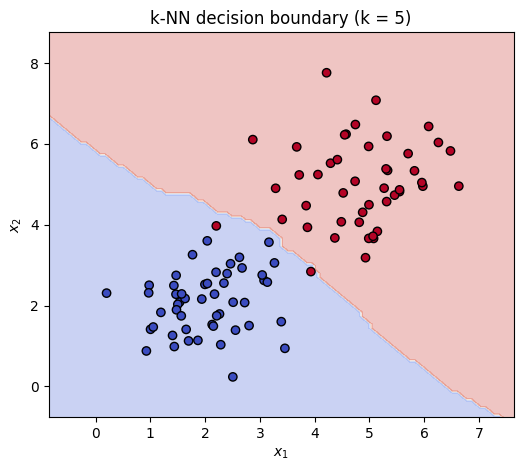

In [3]:
# Visualize the decision boundary: the prediction at every point of a fine grid.
pad = 1.0
x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
grid = np.c_[xx.ravel(), yy.ravel()]

zz = np.array([knn_predict(X_train, y_train, p, k=5) for p in grid]).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, zz, alpha=0.3, cmap="coolwarm")
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm", edgecolor="k")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$")
plt.title("k-NN decision boundary (k = 5)")
plt.show()

## Classifier 2: A Decision Tree (it *is* a tree!)

A **decision tree** classifies by asking a sequence of yes/no questions about the features — "is $x_1 < 3.4$?" — following the branches until it reaches a leaf that gives the answer. That structure is exactly the **binary tree** of notebook 11: internal nodes are decisions, leaves are predictions.

We train one with `scikit-learn` and then draw the learned tree.

decision tree test accuracy: 100%


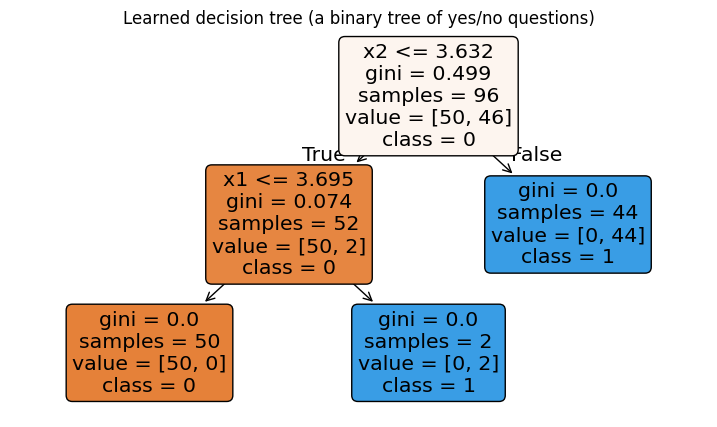

In [4]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree = DecisionTreeClassifier(max_depth=3, random_state=0)
tree.fit(X_train, y_train)
print(f"decision tree test accuracy: {tree.score(X_test, y_test):.0%}")

plt.figure(figsize=(9, 5))
plot_tree(tree, filled=True, rounded=True,
          feature_names=["x1", "x2"], class_names=["0", "1"])
plt.title("Learned decision tree (a binary tree of yes/no questions)")
plt.show()

## Counting and Probability: Naive Bayes

A third family of models comes straight from **counting** (notebook 15) and probability. A **Naive Bayes** classifier estimates probabilities by *counting* how often things occur in the training data, then uses Bayes' rule:

$$P(\text{class} \mid \text{features}) \;\propto\; P(\text{class}) \prod_i P(\text{feature}_i \mid \text{class}).$$

Each $P(\cdot)$ is just a frequency — a count divided by a total. This is why spam filters, which count word occurrences, are often Naive Bayes models. The combinatorics of notebook 15 is doing the work under the hood.

## Wrap-Up

Two different classifiers, one dataset — and underneath both:

- the dataset is a **set** of examples stored as a **matrix**;
- the model is a **function** from inputs to labels;
- distances, neighborhoods, votes, and tree splits are the **discrete structures** you have studied all term;
- a decision tree is a **binary tree**, a neural network is a **graph**, and Naive Bayes is **counting**.

Machine learning is not a separate subject bolted on at the end — it is discrete mathematics, applied.

## Worked Examples

A few examples solved with Python. (The exercises in the next section are for you to solve — their solutions live in the matching notebook in `solutions/`.)

### Example 1: Min-Max Normalization

Features are often rescaled to the range $[0, 1]$ so they are comparable. Apply min-max scaling to a feature.

In [5]:
import numpy as np

x = np.array([10., 20., 30., 40., 50.])
x_scaled = (x - x.min()) / (x.max() - x.min())
print("original:", x)
print("scaled  :", x_scaled)

original: [10. 20. 30. 40. 50.]
scaled  : [0.   0.25 0.5  0.75 1.  ]


### Example 2: Computing Accuracy

Accuracy is the fraction of predictions that match the true labels. Compute it for a set of predictions.

In [6]:
import numpy as np

y_true = np.array([1, 0, 1, 1, 0])
y_pred = np.array([1, 0, 0, 1, 0])
print("accuracy:", np.mean(y_true == y_pred))

accuracy: 0.8


## Machine Learning Practice Problems

Write your Python in the code cell beneath each problem (some starter code is provided). Worked solutions are in [`solutions/16_ml_key.ipynb`](solutions/16_ml_key.ipynb).

### Problem 1: Euclidean Distance

Using NumPy, write a function that returns the Euclidean distance between two points, and use it on $(1, 2)$ and $(4, 6)$. (This is the distance metric behind k-NN.)

In [7]:
import numpy as np
# WRITE YOUR CODE BELOW


### Problem 2: Majority Vote

k-NN labels a point by majority vote of its neighbors. Given a list of neighbor labels, return the most common label. (Hint: `collections.Counter`.)

In [8]:
from collections import Counter
labels = [0, 1, 1, 0, 1]
# WRITE YOUR CODE BELOW


### Problem 3: Class Probabilities by Counting

A Naive Bayes classifier estimates $P(\text{class})$ by counting. For the labels in the starter, compute the probability of each class as (count / total).

In [9]:
from collections import Counter
labels = ["spam", "ham", "spam", "spam", "ham"]
# WRITE YOUR CODE BELOW


### Problem 4: Train a Decision Tree

Train a `scikit-learn` decision tree on the logical AND function ($y = x_1 \land x_2$) and report its accuracy on the training data.

In [10]:
from sklearn.tree import DecisionTreeClassifier
X = [[0, 0], [0, 1], [1, 0], [1, 1]]
y = [0, 0, 0, 1]   # AND
# WRITE YOUR CODE BELOW
